# Test of the Reciever Simulator


In [103]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [104]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p')

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 1024))

open_load = Load(physical_temperature=273,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=273,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=273,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=273,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=273,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+40,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


test_src = Load(physical_temperature=350,
                termination_impedence=75*un.Ohm,
                freqs=test_receiver.freqs,
                effective_cable_length=5*un.m,
                label='Test_src')


observation_handler_obj = ObservationHandler(observation_length=4*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load,
                                                      test_src,
                                                      test_src,
                                                      test_src,
                                                      test_src],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=300*un.s,
                                            delta_t=1*un.s,
                                            n_t_unc_freq_coeffs=5,
                                            n_t_unc_time_coeffs=2,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=3,
                                            n_t_cos_freq_coeffs=4,
                                            n_t_cos_time_coeffs=4)



Done


In [105]:
os.makedirs('simulated_data',
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath="simulated_data/sim_data.hdf5")


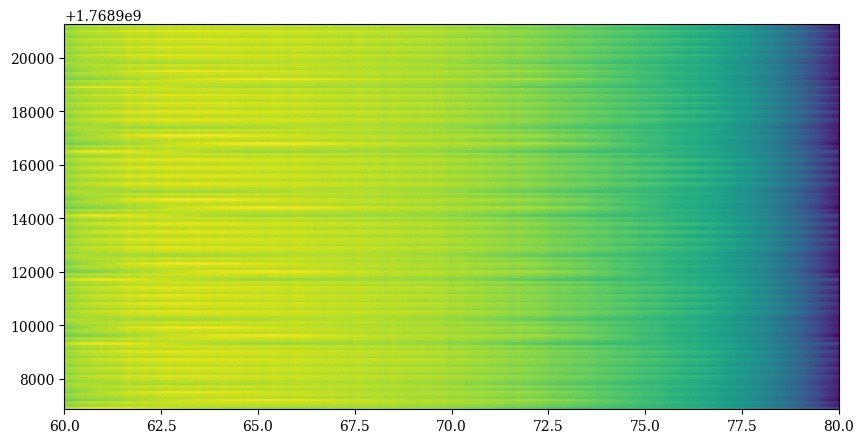

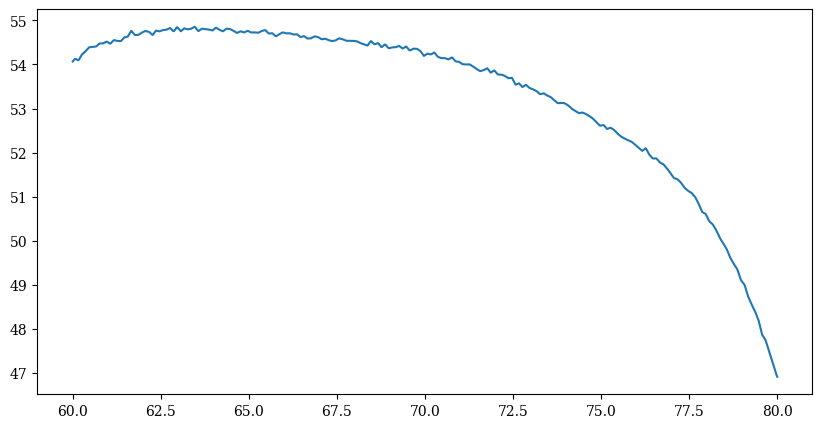

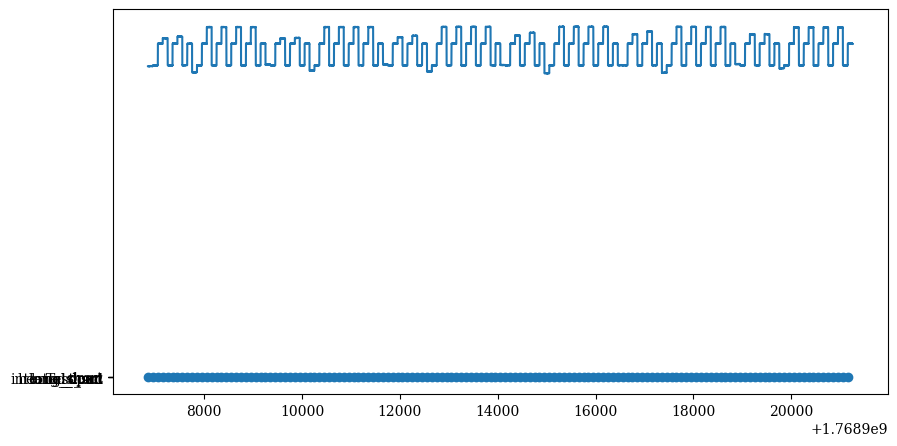

<class 'str'>
<class 'numpy.float64'>
internal_load
[272.99415182 273.10661374 273.04244288 ... 272.97115334 273.20997611
 272.97536752]
----
heated_load
[313.06711254 313.07917314 313.15383694 ... 313.01648691 313.02996229
 312.9349085 ]
----
long_open
[273.13885696 272.99003993 273.00358131 ... 272.8091121  273.0036826
 273.03120808]
----
long_short
[273.11466746 272.9714955  273.09691203 ... 273.00776311 272.93877573
 273.03231523]
----
open
[272.98327668 273.06239299 273.02109629 ... 272.95875879 273.05109045
 272.87234948]
----
short
[273.01559548 272.99214265 272.96856423 ... 272.85947344 272.84200239
 273.22224286]
----
Test_src
[349.93349813 349.9174969  349.87535371 ... 349.96454914 350.07303018
 350.07417218]
----


In [106]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.scatter(observation_handler_obj.switch_times, observation_handler_obj.switch_states)
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


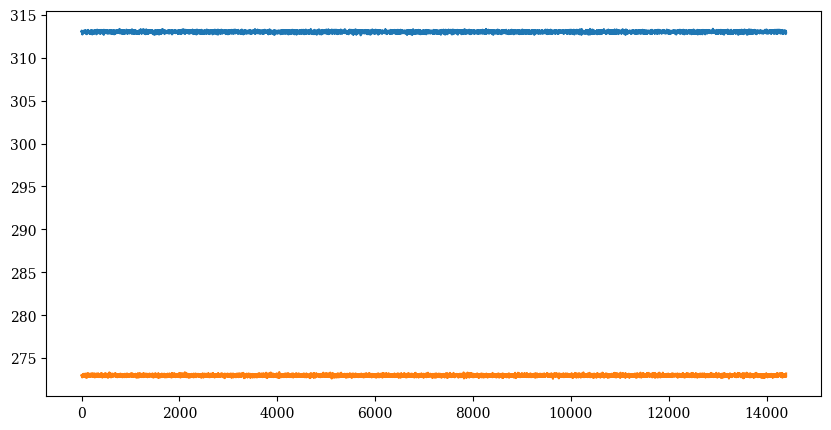

In [107]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [108]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False


In [109]:
print(final_states)

[np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short')]


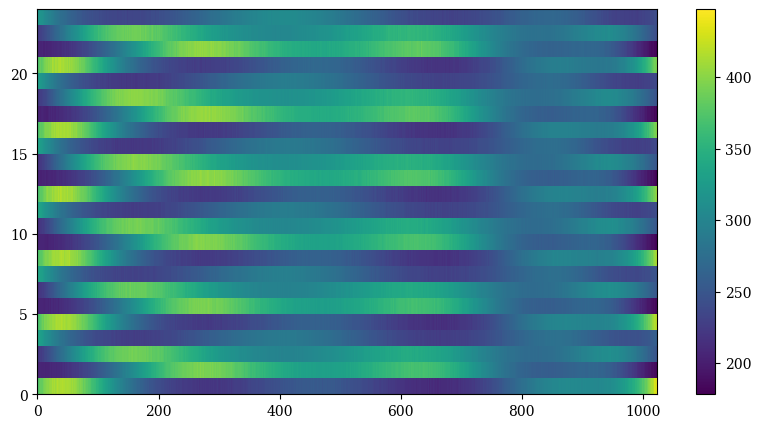

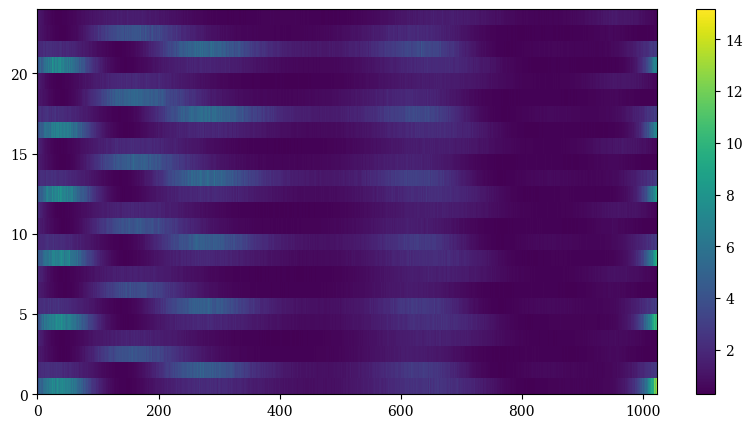

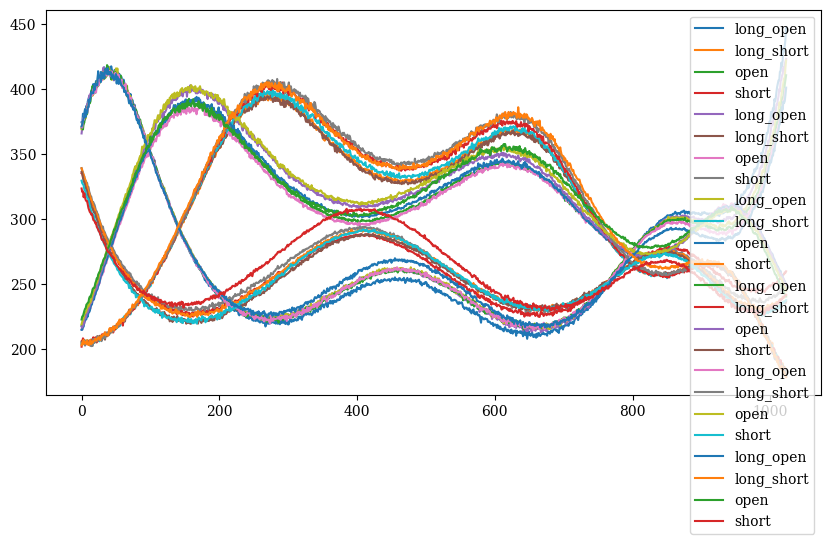

In [110]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [111]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

<class 'float'>
8640000.0


In [112]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)


<function array_normalisation.<locals>.array_norm_func at 0x17273af20>


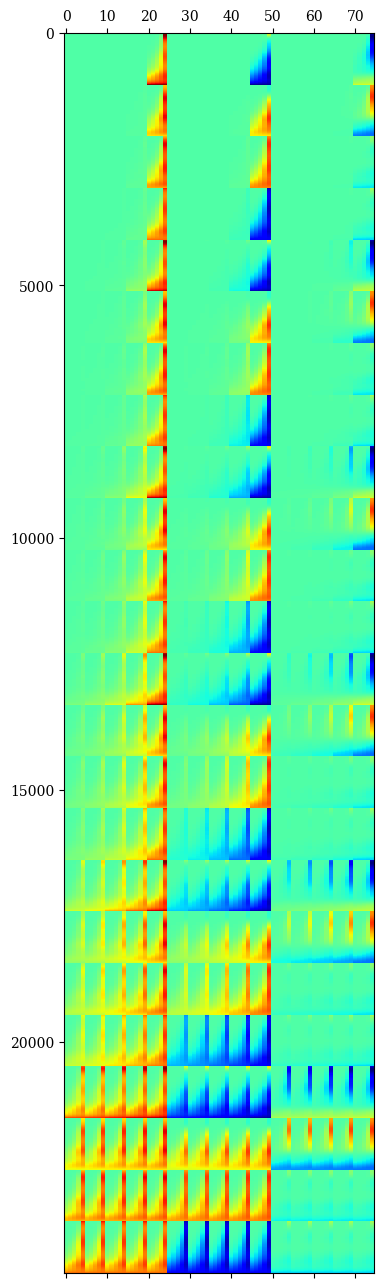

In [113]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

(24576,)
(24576, 75)
[ 3.95579668e+02 -6.93770035e+02  3.47766285e+02 -3.69419564e+01
 -2.47238445e+00 -6.84622347e+02  1.17398710e+03 -5.49934643e+02
  3.40998933e+01  7.92532700e+00  3.78222498e+02 -6.31904192e+02
  2.70124879e+02  1.16180861e+00 -6.71588091e+00  5.55170984e+01
 -1.95425100e+02  9.99449305e+01  1.78051738e+01 -1.06402119e+00
  1.89978171e+02 -1.01740959e+02 -1.08618018e+02  4.55264131e+01
  2.95360850e+02  3.94547735e+02 -7.71327134e+02  4.85126376e+02
 -9.78772597e+01 -5.13151578e-01 -7.34255980e+02 -9.65042740e+02
  3.12711994e+03 -1.43596147e+03 -2.31988004e+01  4.24331989e+02
  1.84421201e+03 -4.14200227e+03  1.78572526e+03  7.00030770e+01
 -8.66050401e+01 -3.25222844e+02  9.18497800e+02 -4.22425345e+02
 -3.84536121e+01  3.57568139e+00  1.53945642e+02 -2.53054533e+02
  1.04386193e+02  1.52280864e+01  5.42469609e+02 -6.93410398e+02
  1.35201335e+02  3.82043485e+01 -1.44515969e-01 -1.05167509e+03
  1.49696107e+03 -4.89093298e+02  9.71309007e+00 -6.86174062e+00
  5.

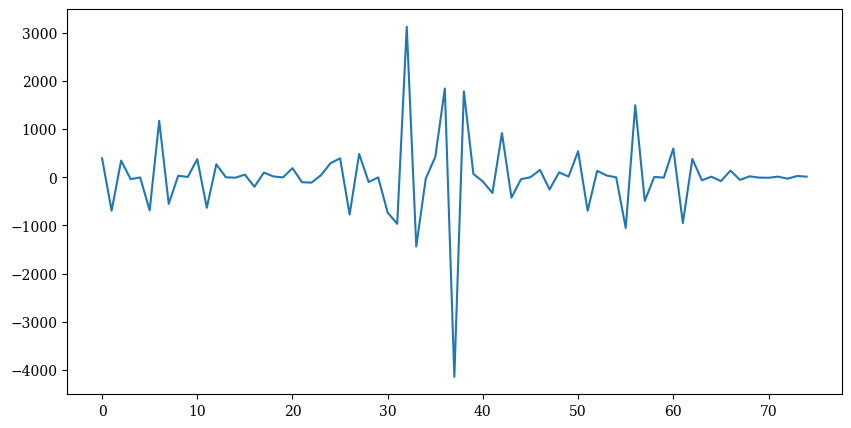

In [114]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [115]:
from gcr.basis_construction import reconstruct_surface

In [116]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

[ 3.95579668e+02 -6.93770035e+02  3.47766285e+02 -3.69419564e+01
 -2.47238445e+00 -6.84622347e+02  1.17398710e+03 -5.49934643e+02
  3.40998933e+01  7.92532700e+00  3.78222498e+02 -6.31904192e+02
  2.70124879e+02  1.16180861e+00 -6.71588091e+00  5.55170984e+01
 -1.95425100e+02  9.99449305e+01  1.78051738e+01 -1.06402119e+00
  1.89978171e+02 -1.01740959e+02 -1.08618018e+02  4.55264131e+01
  2.95360850e+02]
[ 3.94547735e+02 -7.71327134e+02  4.85126376e+02 -9.78772597e+01
 -5.13151578e-01 -7.34255980e+02 -9.65042740e+02  3.12711994e+03
 -1.43596147e+03 -2.31988004e+01  4.24331989e+02  1.84421201e+03
 -4.14200227e+03  1.78572526e+03  7.00030770e+01 -8.66050401e+01
 -3.25222844e+02  9.18497800e+02 -4.22425345e+02 -3.84536121e+01
  3.57568139e+00  1.53945642e+02 -2.53054533e+02  1.04386193e+02
  1.52280864e+01]
[ 5.42469609e+02 -6.93410398e+02  1.35201335e+02  3.82043485e+01
 -1.44515969e-01 -1.05167509e+03  1.49696107e+03 -4.89093298e+02
  9.71309007e+00 -6.86174062e+00  5.99034258e+02 -9.48

In [117]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


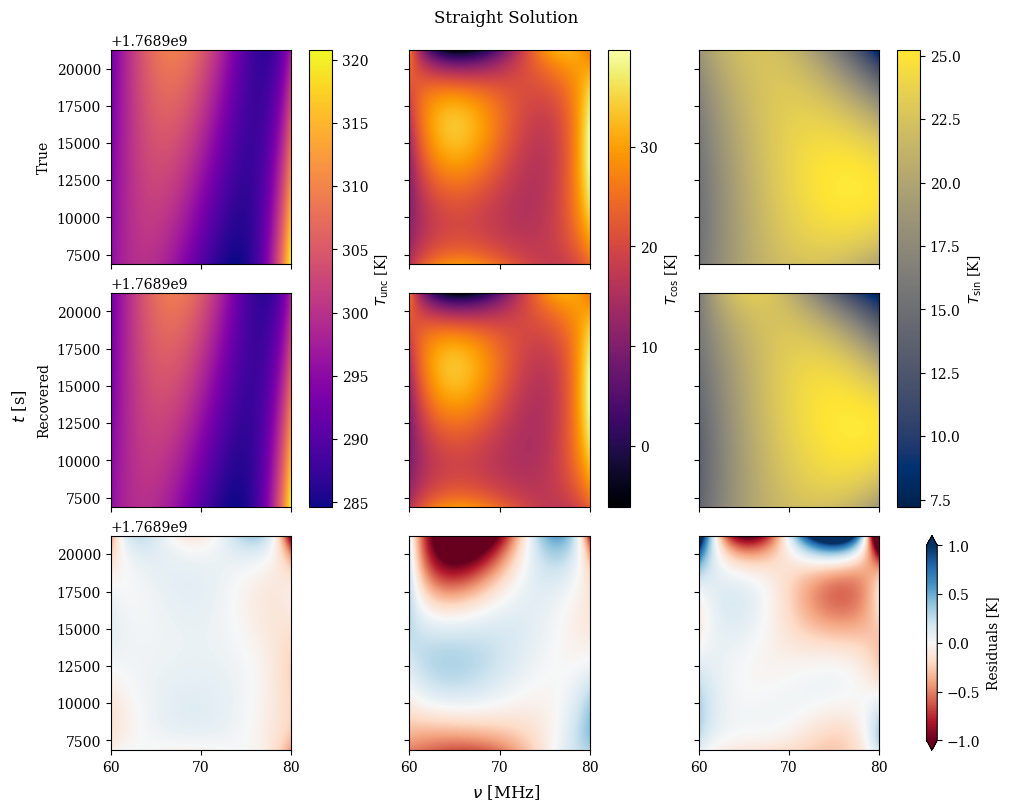

In [118]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [119]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 2
S_inv = np.zeros_like(t_vec)# 1/S_cov
S_inv = 1/S_cov #  np.zeros_like(t_vec)# 1/S_cov

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.random.normal(loc=0, scale=1, size=flattened_data.shape),
                        omega_t=np.random.normal(loc=0, scale=1, size=t_vec.shape))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]


In [120]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


[ 3.95572677e+02 -6.93780110e+02  3.47760645e+02 -3.69606525e+01
 -2.50714737e+00 -6.84632922e+02  1.17398420e+03 -5.49942590e+02
  3.40890144e+01  7.90030980e+00  3.78219982e+02 -6.31908065e+02
  2.70127938e+02  1.16152109e+00 -6.73143473e+00  5.55206491e+01
 -1.95419741e+02  9.99616465e+01  1.78248869e+01 -1.04275121e+00
  1.89960003e+02 -1.01754686e+02 -1.08619558e+02  4.55400750e+01
  2.95347412e+02]
[ 3.94539789e+02 -7.71338501e+02  4.85123042e+02 -9.78813411e+01
 -5.30020857e-01 -7.34267183e+02 -9.65052345e+02  3.12711813e+03
 -1.43596389e+03 -2.32082309e+01  4.24329249e+02  1.84421060e+03
 -4.14200628e+03  1.78573105e+03  7.00071049e+01 -8.66084612e+01
 -3.25226107e+02  9.18500938e+02 -4.22423473e+02 -3.84469825e+01
  3.57679136e+00  1.53942479e+02 -2.53069027e+02  1.04372611e+02
  1.52157619e+01]
[ 5.42454813e+02 -6.93432595e+02  1.35180889e+02  3.81813865e+01
 -1.43608192e-01 -1.05169677e+03  1.49694169e+03 -4.89121792e+02
  9.68655487e+00 -6.86839094e+00  5.99015478e+02 -9.48

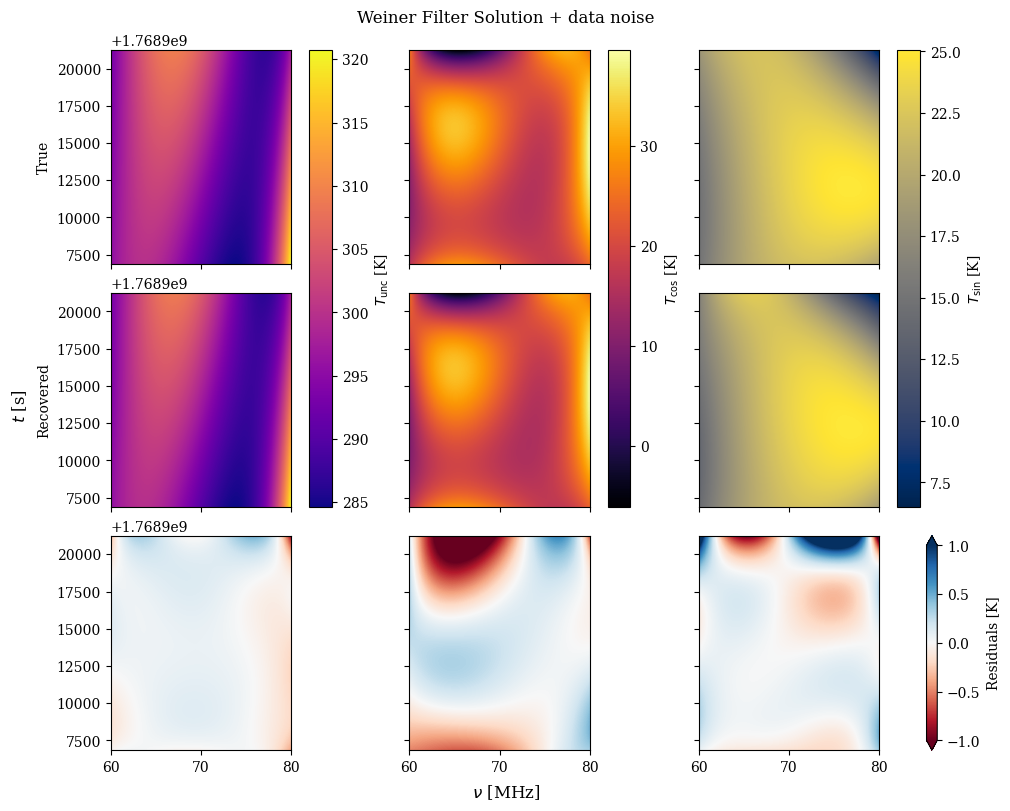

In [121]:

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution + data noise')
plt.show()


In [122]:
t_vec - gcr_wsol

array([ 0.00699139,  0.01007534,  0.00564004,  0.01869615,  0.03476292,
        0.01057525,  0.00290013,  0.00794638,  0.01087887,  0.0250172 ,
        0.00251539,  0.00387292, -0.00305825,  0.00028752,  0.01555382,
       -0.00355069, -0.00535945, -0.01671595, -0.01971309, -0.02126998,
        0.01816738,  0.01372697,  0.00153998, -0.01366189,  0.01343822,
        0.00794632,  0.0113673 ,  0.00333347,  0.0040814 ,  0.01686928,
        0.0112038 ,  0.00960555,  0.00181441,  0.00241981,  0.00943049,
        0.00274054,  0.00141193,  0.00401339, -0.00579009, -0.0040279 ,
        0.00342119,  0.003263  , -0.00313813, -0.00187136, -0.00662965,
       -0.00110997,  0.00316317,  0.01449366,  0.0135825 ,  0.01232458,
        0.01479544,  0.02219685,  0.02044525,  0.02296199, -0.00090778,
        0.02168425,  0.01937918,  0.02849379,  0.0265352 ,  0.00665033,
        0.0187801 ,  0.02752406,  0.02760386,  0.03683001,  0.00192124,
        0.0269272 ,  0.02693733,  0.0394986 ,  0.04106746,  0.00